# **Bakery Market Basket Analysis**

## **1. Import Library**
Pertama-tama mengimpor library yang akan kita gunakan untuk analisis eksplorasi data dan visualisasi data.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## **2. Import**

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline
!wget https://raw.githubusercontent.com/viktree/curly-octo-chainsaw/ea4fbb632382c44af0d0b53c90f4e04496926b94/BreadBasket_DMS.csv -O dataset

--2026-05-19 04:00:05--  https://raw.githubusercontent.com/viktree/curly-octo-chainsaw/ea4fbb632382c44af0d0b53c90f4e04496926b94/BreadBasket_DMS.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 710518 (694K) [text/plain]
Saving to: ‘dataset’

dataset             100%[===================>] 693.87K  --.-KB/s    in 0.03s   

2026-05-19 04:00:05 (24.2 MB/s) - ‘dataset’ saved [710518/710518]



In [3]:
# Menampilkan isi Datasets:
dataset = pd.read_csv('dataset')
dataset

,Date,Time,Transaction,Item
0,2016-10-30,09:58:11,1,Bread
1,2016-10-30,10:05:34,2,Scandinavian
2,2016-10-30,10:05:34,2,Scandinavian
3,2016-10-30,10:07:57,3,Hot chocolate
4,2016-10-30,10:07:57,3,Jam
...,...,...,...,...
21288,2017-04-09,14:32:58,9682,Coffee
21289,2017-04-09,14:32:58,9682,Tea
21290,2017-04-09,14:57:06,9683,Coffee
21291,2017-04-09,14:57:06,9683,Pastry


Dari tabel diatas, menunjukkan jumlah data pada dataset terdapat 21293 baris dan 4 kolom

## **3. Data Preparation**
Pada tahapan ini kita akan memastikan tipe data yang digunakan sesuai, tidak ada nilai kosong

In [4]:
# cek tipe data dari setiap kolom
df = pd.read_csv('dataset')
print(df.dtypes)

Date           object
Time           object
Transaction     int64
Item           object
dtype: object


In [5]:
# mencetak 10 data pertama
print(df.head(10))

         Date      Time  Transaction           Item
0  2016-10-30  09:58:11            1          Bread
1  2016-10-30  10:05:34            2   Scandinavian
2  2016-10-30  10:05:34            2   Scandinavian
3  2016-10-30  10:07:57            3  Hot chocolate
4  2016-10-30  10:07:57            3            Jam
5  2016-10-30  10:07:57            3        Cookies
6  2016-10-30  10:08:41            4         Muffin
7  2016-10-30  10:13:03            5         Coffee
8  2016-10-30  10:13:03            5         Pastry
9  2016-10-30  10:13:03            5          Bread


In [6]:
#Mencetak jumlah data item yang unik (memiliki nilai item berbeda)
jumlah_item_unik = df['Item'].nunique()
print("Jumlah data item yang unik:", jumlah_item_unik)

Jumlah data item yang unik: 95


In [7]:
#Mencetak data item yang unik (memiliki nilai item berbeda)
data_item_unik = df['Item'].drop_duplicates()

print("Data item yang unik:")
for item in data_item_unik:
    print(item)

Data item yang unik:
Bread
Scandinavian
Hot chocolate
Jam
Cookies
Muffin
Coffee
Pastry
Medialuna
Tea
NONE
Tartine
Basket
Mineral water
Farm House
Fudge
Juice
Ella's Kitchen Pouches
Victorian Sponge
Frittata
Hearty & Seasonal
Soup
Pick and Mix Bowls
Smoothies
Cake
Mighty Protein
Chicken sand
Coke
My-5 Fruit Shoot
Focaccia
Sandwich
Alfajores
Eggs
Brownie
Dulce de Leche
Honey
The BART
Granola
Fairy Doors
Empanadas
Keeping It Local
Art Tray
Bowl Nic Pitt
Bread Pudding
Adjustment
Truffles
Chimichurri Oil
Bacon
Spread
Kids biscuit
Siblings
Caramel bites
Jammie Dodgers
Tiffin
Olum & polenta
Polenta
The Nomad
Hack the stack
Bakewell
Lemon and coconut
Toast
Scone
Crepes
Vegan mincepie
Bare Popcorn
Muesli
Crisps
Pintxos
Gingerbread syrup
Panatone
Brioche and salami
Afternoon with the baker
Salad
Chicken Stew
Spanish Brunch
Raspberry shortbread sandwich
Extra Salami or Feta
Duck egg
Baguette
Valentine's card
Tshirt
Vegan Feast
Postcard
Nomad bag
Chocolates
Coffee granules 
Drinking chocolate spoo

In [8]:
# Cek missing value dan zeros
df = pd.read_csv('dataset')
print("Missing values :")
print(df.isnull().sum())
print("Zeros pada kolom :")
print((df == 0).sum())

Missing values :
Date           0
Time           0
Transaction    0
Item           0
dtype: int64
Zeros pada kolom :
Date           0
Time           0
Transaction    0
Item           0
dtype: int64


Terlihat bahwa pada dataset tidak terdapat missing value dan zeros

In [9]:
# cek nilai "NONE" pada kolom Item
print("Nilai NONE pada kolom :", len(df[df['Item'] == 'NONE']))

Nilai NONE pada kolom : 786


Terdapat nilai 'NONE' di dataset kita. Ini bisa berarti bahwa ada item yang tidak dibeli, atau nama item tersebut tidak dicatat. Terdapat 786 data dengan nilai "None" dari total 21293. Karena data ini tidak berguna, maka bisa kita hapus saja.

In [10]:
# menghapus baris dengan nilai Item = None
df = df[df['Item'] != 'NONE']

In [11]:
# cek perubahan yang terjadi
print("Jumlah baris setelah NONE dihapus :", len(df))

Jumlah baris setelah NONE dihapus : 20507


Jumlah baris setelah NONE dihapus : 20507

Seperti yang bisa kita lihat di atas, fitur Tanggal dan Waktu bukanlah tipe numerik. Untuk visualisasi dan pemahaman data yang lebih baik, kita bisa menambahkan beberapa fitur lagi ke DataFrame ini berdasarkan informasi dari dua fitur ini.

In [12]:
# Year (ingat kembali penulisan function lambda)
df['Year'] = df['Date'].apply(lambda x: x.split("-")[0])
# Month
df['Month'] = df['Date'].apply(lambda x: x.split("-")[1])
# Day
df['Day'] = df['Date'].apply(lambda x: x.split("-")[2])

In [13]:
# cek kembali perubahan yang terjadi setelah nilai tahun, bulan dan hari ditampung di fitur baru (year, month, day)
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 20507 entries, 0 to 21292
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         20507 non-null  object
 1   Time         20507 non-null  object
 2   Transaction  20507 non-null  int64 
 3   Item         20507 non-null  object
 4   Year         20507 non-null  object
 5   Month        20507 non-null  object
 6   Day          20507 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.3+ MB
None
         Date      Time  Transaction           Item  Year Month Day
0  2016-10-30  09:58:11            1          Bread  2016    10  30
1  2016-10-30  10:05:34            2   Scandinavian  2016    10  30
2  2016-10-30  10:05:34            2   Scandinavian  2016    10  30
3  2016-10-30  10:07:57            3  Hot chocolate  2016    10  30
4  2016-10-30  10:07:57            3            Jam  2016    10  30


## **4. Visualisasi dan Memahami Data**
Kita tahu bahwa dataset ini direkam dari 30/10/2016 hingga 09/04/2017. Sebelum kita masuk dalam pemodelan, kita harus mengeksplorasi dan memvisualisasikan penjualan dalam periode waktu ini. Barang apa yang paling banyak dibeli pelanggan? Bulan mana yang lebih sukses? Mari kita jawab ini secara visual.


In [14]:
# Menghitung 20 data penjualan item terbanyak
top_items = df['Item'].value_counts().head(20)

# Mencetak 20 data penjualan item terbanyak
print("20 data penjualan item terbanyak:")
print(top_items)

20 data penjualan item terbanyak:
Item
Coffee           5471
Bread            3325
Tea              1435
Cake             1025
Pastry            856
Sandwich          771
Medialuna         616
Hot chocolate     590
Cookies           540
Brownie           379
Farm House        374
Muffin            370
Alfajores         369
Juice             369
Soup              342
Scone             327
Toast             318
Scandinavian      277
Truffles          193
Coke              185
Name: count, dtype: int64


In [15]:
transaction_count = df.groupby(by='Item')[['Transaction']].count().sort_values(by='Transaction', ascending=False)
def convert_to_percentage(x):
    return 100 * x / float(x.sum())

transaction_percentage = transaction_count.apply(convert_to_percentage)
transaction_percentage.head()

,Transaction
Item,
Coffee,26.678695
Bread,16.213976
Tea,6.997611
Cake,4.998293
Pastry,4.174184


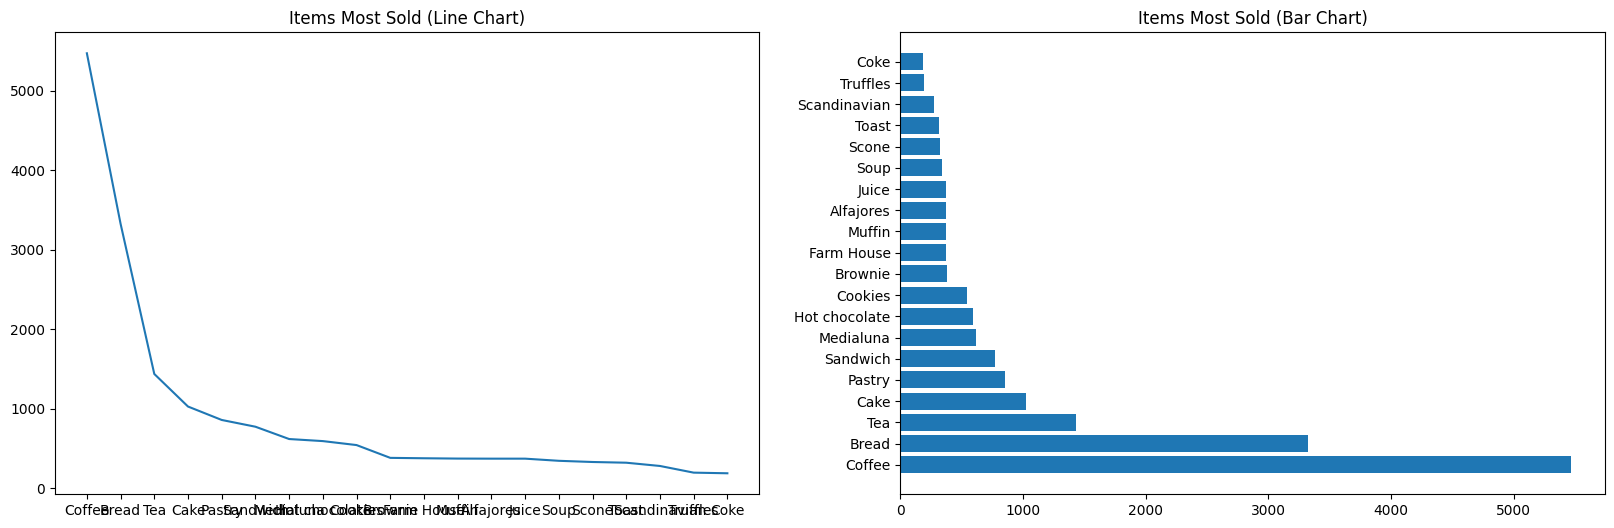

In [16]:
# Visualisasikan data penjualan item terbanyak ke line chart dan bar chart
# Menghitung 20 data penjualan item terbanyak
top_items = df['Item'].value_counts().head(20)

# Menampilkan visualisasi data dalam bentuk line chart
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(top_items)
plt.title('Items Most Sold (Line Chart)')

# Menampilkan visualisasi data dalam bentuk bar chart
plt.subplot(1,2,2)
plt.barh(top_items.index, top_items.values)
plt.title('Items Most Sold (Bar Chart)')

plt.show()

Berdasarkan hasil visualisasi, sebutkan 3 barang yang paling banyak terjual !
=>


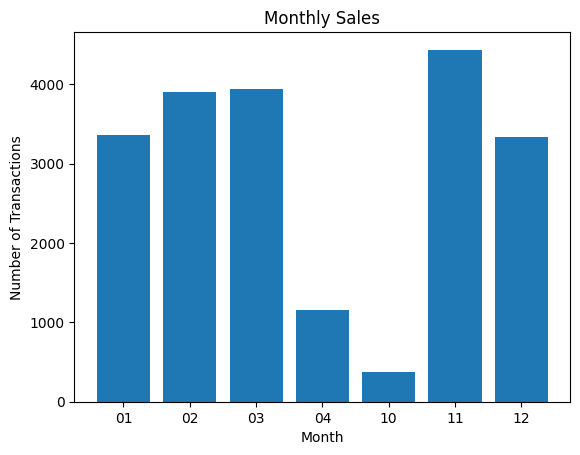

In [17]:
#buat visualisasi data diagram batang dengan judul 'Monthly Sales' dengan sumbu x bulan dan sumbu y jumlah transaksi
monthly_sales = df['Month'].value_counts().sort_index()

plt.bar(monthly_sales.index, monthly_sales.values)
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.title('Monthly Sales')

plt.show()

Dari hasil visualisasi data penjualan perbulan, terlihat terjadi perbedaan penjualan yang drastis pada bulan 4 dan 10 ini disebut dengan outlier.
Untuk mengetahui lebih lanjut, kita bisa periksa untuk melihat apakah ada lebih sedikit transaksi harian yang dicatat untuk bulan-bulan ini dibandingkan dengan yang lain.

In [18]:
print(df.groupby('Month')['Day'].nunique())

Month
01    30
02    28
03    31
04     9
10     2
11    30
12    29
Name: Day, dtype: int64


Pada Bulan 4 hanya tercatat 9 hari dan pada bulan  10 hanya tercatat 2 hari

## **5. Market Basket Analysis**

Pertama kita mengubah item list menjadi data transaksi dengan menggunakan TransactionEncoder.
Kita akan menggunakan frequent item-sets untuk menghasilkan aturan asosiasi dengan menggunakan algoritma Apriori.


In [19]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules, apriori

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


kita membuat list transaction_list() yang unik sehingga kita dapat mengubah data kita ke dalam format yang benar

In [20]:
transaction_list = []

# For loop to create a list of the unique transactions throughout the dataset:
for i in df['Transaction'].unique():
    tlist = list(set(df[df['Transaction']==i]['Item']))
    if len(tlist)>0:
        transaction_list.append(tlist)
print(len(transaction_list))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

9465


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

kita menggunakan TransactionEncoder untuk merubah bentuk transaction_list()

In [21]:
te = TransactionEncoder()
te_ary = te.fit(transaction_list).transform(transaction_list)
df2 = pd.DataFrame(te_ary, columns=te.columns_)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Sekarang kita terapkan Apriori. Kita akan menggunakan parameter min_threshold (nilai ambang batas yang ditentukan) dalam aturan asosiasi untuk metrik lift menjadi 1,0 karena jika kurang dari satu, maka kedua item tersebut kemungkinan tidak akan dibeli bersama. Kita akan mengurutkan nilai berdasarkan keyakinan untuk melihat kemungkinan suatu barang dibeli jika pendahulunya dibeli.

In [22]:
frequent_itemsets = apriori(df2, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift" , min_threshold=1.0)
metrix = pd.DataFrame(rules)
metrix[['antecedents','consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
38,"(Tea, Coffee)",(Cake),0.010037,0.201271,1.937977
41,(Cake),"(Tea, Coffee)",0.010037,0.096643,1.937977
9,(Cake),(Hot chocolate),0.011410,0.109868,1.883874
8,(Hot chocolate),(Cake),0.011410,0.195652,1.883874
10,(Tea),(Cake),0.023772,0.166667,1.604781
11,(Cake),(Tea),0.023772,0.228891,1.604781
31,(Toast),(Coffee),0.023666,0.704403,1.472431
30,(Coffee),(Toast),0.023666,0.049470,1.472431
36,"(Coffee, Bread)",(Pastry),0.011199,0.124413,1.444872
37,(Pastry),"(Coffee, Bread)",0.011199,0.130061,1.444872


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# **Kesimpulan**

Penjelasan nilai-nilai metrik (support, confidence, dan lift)!

**Berdasarkan analisis dengan nilai min_support sebesar 0.01, adapun hasil beberapa aturan asosiasi yang menunjukkan item yang sering dibeli bersamaan antara lain:**
1. Coffee dan Bread.
2. Medialuna dan Coffee.
3. Pastry dan Coffee.
4. Tea dan Coffee.


**Kesimpulannya secara garis besar:**

Aturan-aturan ini menunjukkan bahwa kombinasi produk-produk tersebut memiliki tingkat kejadian yang tinggi, dan pelanggan cenderung membeli item tersebut bersamaan. Ini dapat memberikan wawasan berharga untuk strategi pemasaran, penempatan produk di toko, atau penawaran bundel yang dapat meningkatkan penjualan dan kepuasan pelanggan. Karena Algoritma Apriori membantu mengidentifikasi aturan asosiasi yang dapat memberikan wawasan tentang kecenderungan pelanggan membeli produk bersamaan.

Refrensi Serupa:

https://www.kaggle.com/code/xvivancos/market-basket-analysis